# Fuel–Delay Tradeoff Prediction for Ships
### Cost-optimized speed recommendation framework

This notebook is the single source of truth for the project — run every cell top to bottom.
It covers: data loading, feature engineering, model training, validation, hyperparameter
tuning, and the speed-recommendation engine.

**To use real data:** upload `ship_fuel_efficiency.csv` to the `data/` folder before running
Cell 2 below (or just run as-is first — it falls back to a schema-matched synthetic dataset).

In [12]:
# Cell 1 — install dependencies (Colab already has most of these)
!pip install -q scikit-learn tensorflow matplotlib pandas numpy 2>/dev/null || pip install -q scikit-learn tensorflow matplotlib pandas numpy --break-system-packages

## 1. Setup — clone/create the project files

If you're running this notebook standalone (not alongside the project's .py files),
run the cell below to write them out. If the .py files are already present in this
folder (e.g. you opened this notebook from within the project folder), skip Cell 2.

In [13]:
# Cell 2 — only needed if the .py files aren't already in this folder.
# If data_prep.py etc. already exist alongside this notebook, skip this cell.
import os
print("Files present:", [f for f in os.listdir('.') if f.endswith('.py')])

Files present: ['data_prep.py', 'main.py', 'model_tuning.py', 'pareto.py', 'models.py', 'feature_engineering.py', 'robustness_check.py']


## 2. Load data and engineer features

In [14]:
from data_prep import load_data, NOMINAL_SPEED_KNOTS
from feature_engineering import engineer_all

raw, is_real = load_data()
df = engineer_all(raw)
print(f"Data source: {'REAL Kaggle dataset' if is_real else 'SYNTHETIC placeholder'}")
print(f"Shape: {df.shape}")
df.head()

Data source: REAL Kaggle dataset
Shape: (1440, 21)


,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency,...,implied_speed_knots,nominal_speed_knots,actual_time_hours,expected_time_hours,delay_hours,fuel_price_usd_per_litre,bunker_cost_usd,demurrage_rate_usd_per_hour,demurrage_cost_usd,total_voyage_cost_usd
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14,...,9.663538,10.0,13.686499,13.226,0.460499,0.42,1587.5034,45,20.722470,1608.225870
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98,...,10.650497,10.0,12.067042,12.852,-0.784958,0.42,1873.8048,45,0.000000,1873.804800
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61,...,9.522856,10.0,7.067207,6.730,0.337207,0.42,784.4466,45,15.174335,799.620935
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42,...,10.445671,10.0,6.862173,7.168,-0.305827,0.72,1723.3272,45,0.000000,1723.327200
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61,...,10.188690,10.0,13.183245,13.432,-0.248755,0.42,1792.2198,45,0.000000,1792.219800


## 3. Train the three models

- **Polynomial Regression** — interpretable baseline
- **Random Forest** — main tabular model, handles categorical interactions
- **LSTM** — trained on per-vessel voyage sequences (fuel drift over time)

In [15]:
from models import train_polynomial_regression, train_random_forest, check_lstm_feasibility, train_lstm

_, poly_metrics = train_polynomial_regression(df)
print(poly_metrics)

_, rf_metrics, importance_df = train_random_forest(df)
print(rf_metrics)
importance_df.head(8)

{'model': 'Polynomial Regression (deg=2)', 'MAE': 737.7261253073963, 'R2': 0.9529976813514788}
{'model': 'Random Forest', 'MAE': 674.3209425027043, 'R2': 0.9484041059338971}


,feature,importance
0,distance,0.942816
5,ship_type_Tanker Ship,0.023387
1,engine_efficiency,0.013143
4,ship_type_Surfer Boat,0.013132
10,weather_conditions_Stormy,0.001552
8,weather_conditions_Calm,0.001502
7,fuel_type_HFO,0.001245
9,weather_conditions_Moderate,0.001217


In [16]:
feasible, counts = check_lstm_feasibility(df)
print(f"LSTM feasible: {feasible} (median voyages/ship: {counts.median()})")

if feasible:
    try:
        _, _, lstm_metrics = train_lstm(df)
        print(lstm_metrics)
    except ValueError as e:
        print(f"LSTM skipped: {e}")

LSTM feasible: True (median voyages/ship: 12.0)
{'model': 'LSTM (window=5)', 'MAE': 1966.301664980934, 'R2': 0.4948733065491526, 'n_sequences': 840}


## 4. Validate the Random Forest model

Answers "is this overfitting?" and "is this result stable?" — the two questions
most likely to come up in review.

In [17]:
from robustness_check import run as run_robustness

overfit_result, cv_result, error_result = run_robustness(df)

Running robustness checks on Random Forest...

Train R2: 0.9929 | Test R2: 0.9484 | Gap: 0.0445 | LOW overfitting risk.
5-fold CV -- Mean R2: 0.9479, Std: 0.0050

By ship type:
ship_type
Surfer Boat         16.1
Tanker Ship         14.9
Fishing Trawler     10.1
Oil Service Boat     9.6

By weather:
weather_conditions
Calm        13.1
Moderate    12.6
Stormy      12.1


## 5. Hyperparameter tuning + uncertainty estimates

In [18]:
from model_tuning import tune_random_forest, predict_with_uncertainty
import pandas as pd

tuning_result = tune_random_forest(df, n_iter=30)

Best params: {'model__n_estimators': 300, 'model__min_samples_split': 6, 'model__min_samples_leaf': 6, 'model__max_features': 1.0, 'model__max_depth': 10}
Tuned Test R2: 0.9545 | Baseline Test R2: 0.9484 | Improvement: +0.0061


In [19]:
# Example: predict fuel consumption with a 90% confidence interval
example = pd.DataFrame([{
    "distance": 250, "engine_efficiency": 85,
    "ship_type": "Tanker Ship", "fuel_type": "HFO", "weather_conditions": "Moderate",
}])
unc = predict_with_uncertainty(tuning_result["best_pipe"], example)
print(f"Point estimate: {unc['point_estimate']:.1f} litres")
print(f"90% interval: [{unc['lower_90']:.1f}, {unc['upper_90']:.1f}] litres")

Point estimate: 10701.0 litres
90% interval: [9491.2, 11635.4] litres


## 6. Speed recommendation — the actual decision-support output

For each vessel class, finds the cost-minimizing speed and compares it against
the nominal (scheduled) speed.

In [20]:
from pareto import recommend_speed

for ship_type in NOMINAL_SPEED_KNOTS:
    best, curve, comparison = recommend_speed(df, ship_type, distance=250, fuel_type="HFO", weather="Moderate")
    print(f"{ship_type}:")
    print(f"  Nominal:  {comparison['nominal_speed_knots']:.1f} kn -> ${comparison['nominal_total_cost_usd']:,.0f}")
    print(f"  Optimal:  {comparison['optimal_speed_knots']:.1f} kn -> ${comparison['optimal_total_cost_usd']:,.0f}")
    print(f"  Savings:  ${comparison['savings_usd']:,.0f} ({comparison['savings_pct']:.1f}%)\n")

Oil Service Boat:
  Nominal:  9.9 kn -> $3,434
  Optimal:  5.5 kn -> $1,970
  Savings:  $1,463 (42.6%)

Fishing Trawler:
  Nominal:  7.9 kn -> $2,847
  Optimal:  3.8 kn -> $1,341
  Savings:  $1,506 (52.9%)

Surfer Boat:
  Nominal:  19.9 kn -> $1,685
  Optimal:  10.1 kn -> $863
  Savings:  $822 (48.8%)

Tanker Ship:
  Nominal:  13.9 kn -> $4,662
  Optimal:  8.6 kn -> $3,122
  Savings:  $1,540 (33.0%)



## 7. Delay-tolerance tradeoff

Shows what it costs to guarantee a maximum acceptable delay — i.e. how much extra
you pay to respect a customer's schedule, instead of chasing pure cost minimization.

 max_delay_allowed_hours  speed_knots  actual_delay_hours  total_cost_usd  extra_cost_vs_unconstrained_pct
                0.000000    14.132911            0.000000     4797.688088                        53.674506
                7.653061     9.924051            7.334184     3245.731285                         3.963856
               15.306122     8.594937           11.229750     3121.980475                         0.000000
               22.959184     8.594937           11.229750     3121.980475                         0.000000
               30.612245     8.594937           11.229750     3121.980475                         0.000000
               38.265306     8.594937           11.229750     3121.980475                         0.000000
               45.918367     8.594937           11.229750     3121.980475                         0.000000
               53.571429     8.594937           11.229750     3121.980475                         0.000000


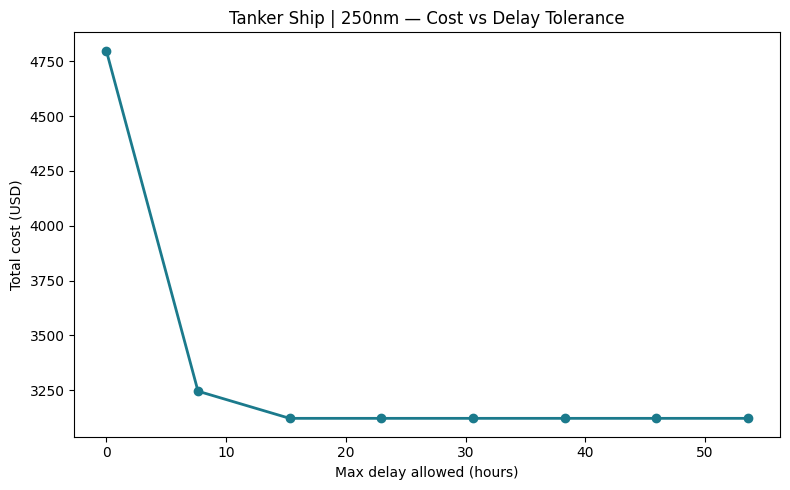

In [21]:
from pareto import recommend_speed_with_max_delay, delay_tolerance_tradeoff
import matplotlib.pyplot as plt

SHIP_TYPE = "Tanker Ship"
DISTANCE = 250

tradeoff = delay_tolerance_tradeoff(df, SHIP_TYPE, DISTANCE)
print(tradeoff.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tradeoff["max_delay_allowed_hours"], tradeoff["total_cost_usd"], marker='o', color="#1B7A8C", linewidth=2)
ax.set_xlabel("Max delay allowed (hours)")
ax.set_ylabel("Total cost (USD)")
ax.set_title(f"{SHIP_TYPE} | {DISTANCE}nm — Cost vs Delay Tolerance")
plt.tight_layout()
plt.show()

## 8. Interactive scenario explorer (Colab form)

Adjust the values below — this cell re-runs automatically (Colab form, top-right of the cell).

1) Normal speed:    13.9 kn -> $4,662
2) Cheapest option: 8.6 kn -> $3,122
3) Your choice:     9.0 kn -> $3,139 (delay: 9.8 hrs)


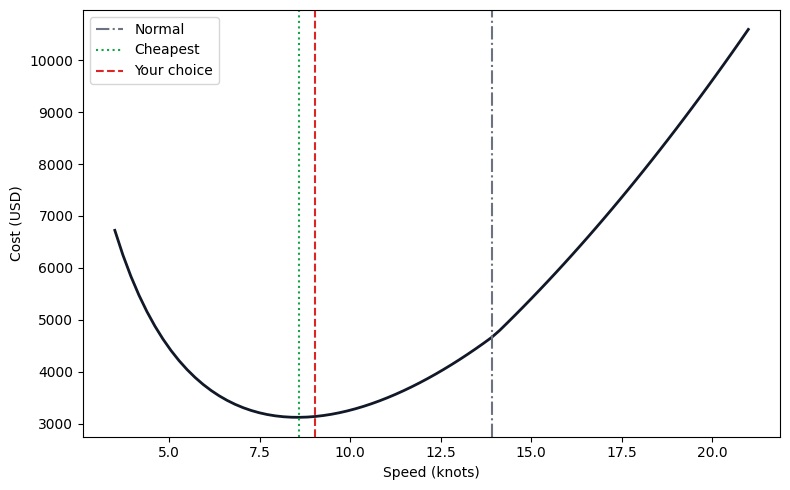

In [22]:
#@title Ship Voyage Planner { run: "auto" }
ship_type = "Tanker Ship" #@param ["Oil Service Boat", "Fishing Trawler", "Surfer Boat", "Tanker Ship"]
distance = 250 #@param {type:"slider", min:20, max:500, step:10}
weather = "Moderate" #@param ["Calm", "Moderate", "Stormy"]
fuel_type = "HFO" #@param ["HFO", "Diesel"]
max_delay_hours = 10 #@param {type:"slider", min:0, max:60, step:1}

best, curve, comparison = recommend_speed(df, ship_type, distance, fuel_type, weather)
result, _ = recommend_speed_with_max_delay(df, ship_type, distance, max_delay_hours, fuel_type, weather)

print(f"1) Normal speed:    {comparison['nominal_speed_knots']:.1f} kn -> ${comparison['nominal_total_cost_usd']:,.0f}")
print(f"2) Cheapest option: {comparison['optimal_speed_knots']:.1f} kn -> ${comparison['optimal_total_cost_usd']:,.0f}")
print(f"3) Your choice:     {result['constrained_speed_knots']:.1f} kn -> ${result['constrained_total_cost_usd']:,.0f} "
      f"(delay: {result['constrained_delay_hours']:.1f} hrs)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve["speed_knots"], curve["total_cost_usd"], color="#111827", linewidth=2)
ax.axvline(comparison['nominal_speed_knots'], color="#6b7280", linestyle="-.", label="Normal")
ax.axvline(comparison['optimal_speed_knots'], color="#16a34a", linestyle=":", label="Cheapest")
ax.axvline(result['constrained_speed_knots'], color="#dc2626", linestyle="--", label="Your choice")
ax.set_xlabel("Speed (knots)")
ax.set_ylabel("Cost (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Item | Status |
|---|---|
| Data pipeline | Complete |
| Feature engineering (implied speed, delay, economic layer) | Complete |
| 3 models trained | Complete |
| Overfitting + cross-validation check | Complete |
| Hyperparameter tuning | Complete |
| Uncertainty estimates | Complete |
| Speed recommendation engine | Complete |
| Delay-tolerance tradeoff | Complete |

**Base paper:** Gkerekos, Lazakis & Theotokatos (2019), *Ocean Engineering*.

In [24]:
from pareto import recommend_speed

for ship_type in NOMINAL_SPEED_KNOTS:
    best, curve, comparison = recommend_speed(df, ship_type, distance=250, fuel_type="HFO", weather="Moderate")
    print(f"{ship_type}:")
    print(f"  Nominal:  {comparison['nominal_speed_knots']:.1f} kn -> ${comparison['nominal_total_cost_usd']:,.0f}")
    print(f"  Optimal:  {comparison['optimal_speed_knots']:.1f} kn -> ${comparison['optimal_total_cost_usd']:,.0f}")
    print(f"  Savings:  ${comparison['savings_usd']:,.0f} ({comparison['savings_pct']:.1f}%)\n")


Oil Service Boat:
  Nominal:  9.9 kn -> $3,434
  Optimal:  5.5 kn -> $1,970
  Savings:  $1,463 (42.6%)

Fishing Trawler:
  Nominal:  7.9 kn -> $2,847
  Optimal:  3.8 kn -> $1,341
  Savings:  $1,506 (52.9%)

Surfer Boat:
  Nominal:  19.9 kn -> $1,685
  Optimal:  10.1 kn -> $863
  Savings:  $822 (48.8%)

Tanker Ship:
  Nominal:  13.9 kn -> $4,662
  Optimal:  8.6 kn -> $3,122
  Savings:  $1,540 (33.0%)



In [25]:
!python3 main.py



DATA SOURCE: REAL Kaggle dataset

[1/5] Polynomial Regression...
  {'model': 'Polynomial Regression (deg=2)', 'MAE': 737.7261253073963, 'R2': 0.9529976813514788}

[2/5] Random Forest...
  {'model': 'Random Forest', 'MAE': 674.3209425027043, 'R2': 0.9484041059338971}
                  feature  importance
                 distance    0.942816
    ship_type_Tanker Ship    0.023387
        engine_efficiency    0.013143
    ship_type_Surfer Boat    0.013132
weather_conditions_Stormy    0.001552

[3/5] LSTM feasibility check...
  Feasible: True (voyages/ship median: 12.0)
2026-09-07 11:06:36.932205: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
  {'model': 'LSTM (window=5)', 'MAE': 1994.5429585774739, 'R2': 0.48355051008641436, 'n_sequences': 840}

[4/5] Robustness validation (overfitting + cross-validation)...
Running robustness checks on Random Forest...

Train R2: 0.9929 | Test R2:

In [27]:
import http.server
import socketserver
import threading
from google.colab import output

PORT = 8000

class Handler(http.server.SimpleHTTPRequestHandler):
    def log_message(self, format, *args):
        pass  # silence server logs

def start_server():
    with socketserver.TCPServer(("", PORT), Handler) as httpd:
        httpd.serve_forever()

server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

print("Opening the website below — this runs live inside Colab.")
output.serve_kernel_port_as_iframe(PORT, path='/voyage_speed_optimizer.html', height=900)


Opening the website below — this runs live inside Colab.


Exception in thread Thread-224 (start_server):


<IPython.core.display.Javascript object>